Running simulation... this may take a moment.
Global MAE: 0.006046
MAE of Tail: 0.020134
Wilcoxon P-value: 1.6932e-165


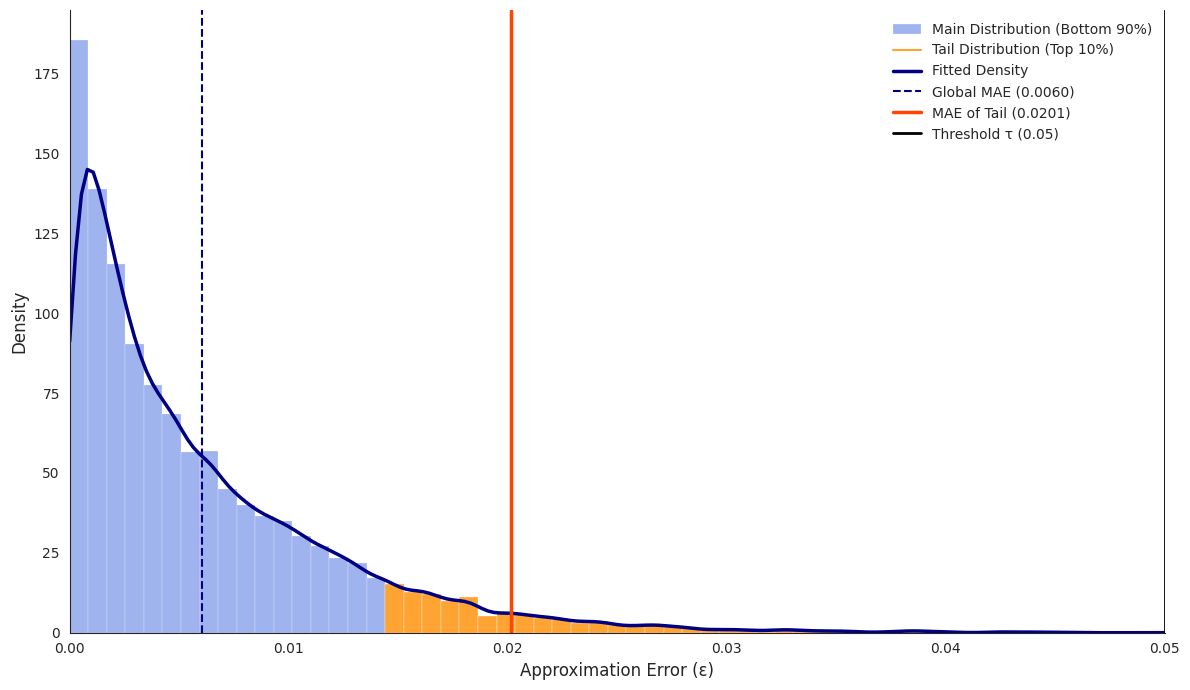

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

# PARAMETERS
N_TRIALS = 10000
TOLERANCE = 1e-8
THRESHOLD = 0.05  # 5% Operational Threshold


def weiszfeld(alpha1, beta1, alpha2, beta2, tol=1e-8):
    # Initial guess: center of gravity (the squared-Euclidean minimizer)
    a_hat = alpha1 / (alpha1 + beta1)
    b_hat = alpha2 / (alpha2 + beta2)

    # Generate demand points for this trial
    points = np.random.beta(alpha1, beta1, size=(1000, 2))
    points[:, 1] = np.random.beta(alpha2, beta2, size=1000)

    curr_a, curr_b = a_hat, b_hat
    for _ in range(500):
        dists = np.sqrt((points[:, 0] - curr_a)**2 + (points[:, 1] - curr_b)**2)
        dists[dists < 1e-10] = 1e-10
        weights = 1.0 / dists
        new_a = np.sum(points[:, 0] * weights) / np.sum(weights)
        new_b = np.sum(points[:, 1] * weights) / np.sum(weights)
        if np.sqrt((new_a - curr_a)**2 + (new_b - curr_b)**2) < tol:
            break
        curr_a, curr_b = new_a, new_b

    # Calculate relative error between approximate and true minimum
    i_star = np.mean(np.sqrt((points[:, 0] - curr_a)**2 + (points[:, 1] - curr_b)**2))
    i_hat = np.mean(np.sqrt((points[:, 0] - a_hat)**2 + (points[:, 1] - b_hat)**2))
    return (i_hat - i_star) / i_star

#   SIMULATION
# This creates the 'errors' variable
np.random.seed(42)
print("Running simulation... this may take a moment.")
errors = np.array([weiszfeld(*np.random.uniform(0.5, 5.0, 4)) for _ in range(N_TRIALS)])

#  STATISTICAL ANALYSIS
cutoff_90 = np.percentile(errors, 90)
tail_mask = errors >= cutoff_90
mae_tail = np.mean(errors[tail_mask])
global_mae = np.mean(errors)

# Wilcoxon Test on the Tail
stat, p_val = wilcoxon(errors[tail_mask] - THRESHOLD, alternative='less')

print(f"Global MAE: {global_mae:.6f}")
print(f"MAE of Tail: {mae_tail:.6f}")
print(f"Wilcoxon P-value: {p_val:.4e}")

# VISUALIZATION
plt.figure(figsize=(12, 7))
sns.set_style("white")
all_bins = np.linspace(0, THRESHOLD, 60)

# Plotting with manual coloring for the tail
n, bins, patches = plt.hist(errors, bins=all_bins, density=True,
                            color='royalblue', alpha=0.5, edgecolor='white',
                            linewidth=0.3, label='Main Distribution (Bottom 90%)')

for i in range(len(patches)):
    if bins[i] >= cutoff_90:
        patches[i].set_facecolor('darkorange')
        patches[i].set_alpha(0.8)

# Dummy plot for legend
plt.plot([], [], color='darkorange', alpha=0.8, label='Tail Distribution (Top 10%)')

# Boundary-aware KDE
sns.kdeplot(errors, color='navy', linewidth=2.5, label='Fitted Density', cut=0, bw_adjust=0.6)

# Reference Lines
plt.axvline(global_mae, color='navy', linestyle='--', linewidth=1.5, label=f'Global MAE ({global_mae:.4f})')
plt.axvline(mae_tail, color='orangered', linestyle='-', linewidth=2.5, label=f'MAE of Tail ({mae_tail:.4f})')
plt.axvline(THRESHOLD, color='black', linewidth=2, label=f'Threshold τ ({THRESHOLD})')

plt.xlim(0, THRESHOLD)
plt.xlabel("Approximation Error (ε)", fontsize=12)
plt.ylabel("Density", fontsize=12)
sns.despine()

# Legend Logic
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), frameon=False, loc='upper right')

plt.tight_layout()
plt.show()